# What is Normalization?

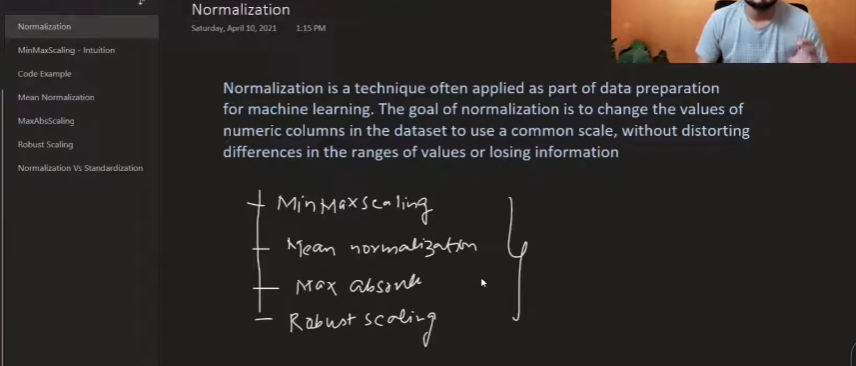

- For example, we have height and weight of a person, and we want to predict whether the person is obese or not. Now both have differnent scales, height is in cm and weight is in kg. So we need to bring them to the same scale. This is where normalization comes in.
- Its always  bettet to eliminate the units of measurement and bring all the features to the same scale. This is done by normalization.

## Min-Max Scaling

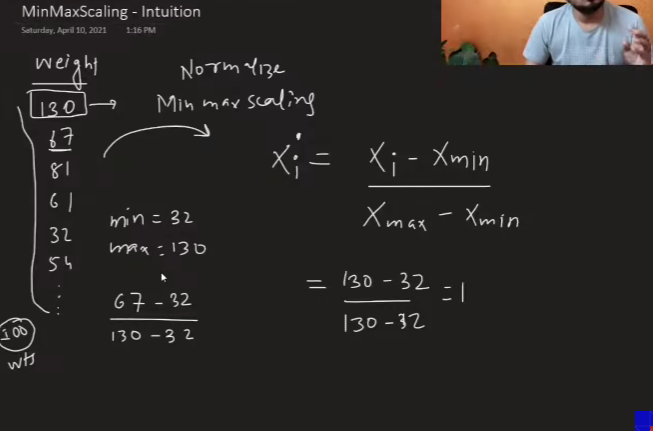

- Kvhi agar bss bole ki normalize kro, then min-max scaling hi use krna.
- Isme hum feature ko 0 aur 1 ke beech le aate hain.
- Iska formula hai: Xi_scaled = (Xi - X_min) / (X_max - X_min)

## Geometrical intuition

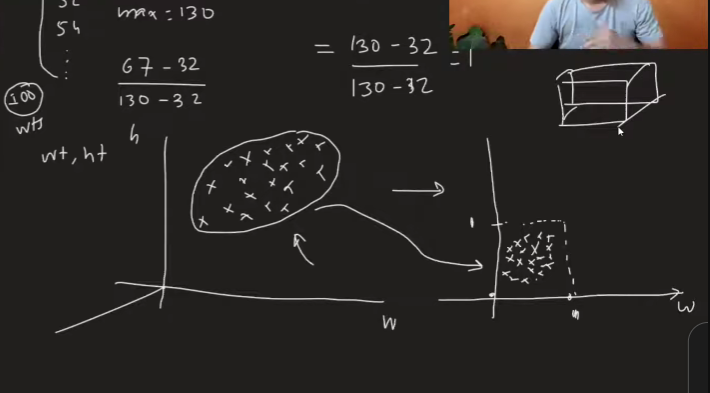

- For a 2D datased, we squish the data to fit in a unit square.
- For a 3D dataset, we squish the data to fit in a unit cube.
- For higher dimensions, we squish the data to fit in a unit hypercube.

### Example of Min-Max Scaling

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2])
df.columns=['Class label', 'Alcohol', 'Malic acid']

In [3]:
df.sample(5)

,Class label,Alcohol,Malic acid
15,1,13.63,1.81
137,3,12.53,5.51
91,2,12.00,1.51
97,2,12.29,1.41
12,1,13.75,1.73


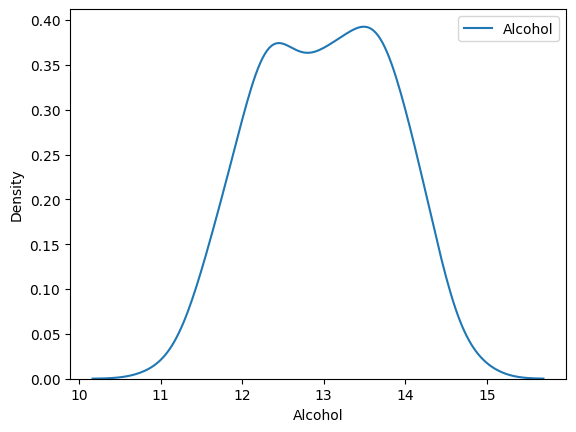

In [9]:
sns.kdeplot(df['Alcohol'], label='Alcohol')
plt.legend()

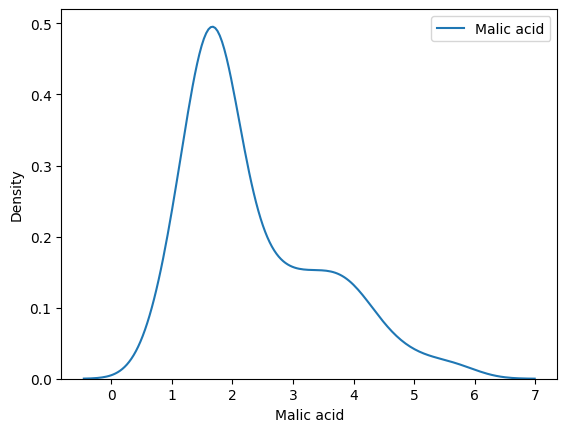

In [11]:
sns.kdeplot(df['Malic acid'], label='Malic acid')
plt.legend()

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

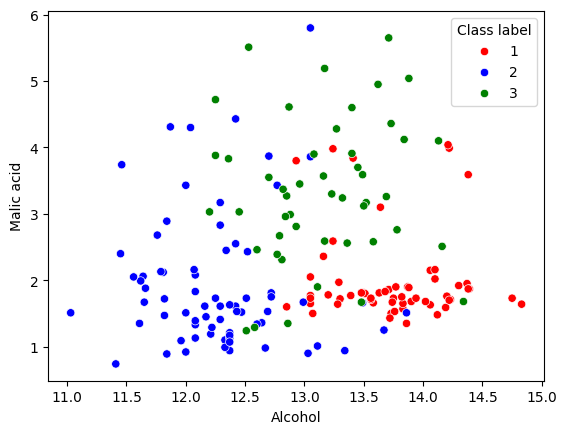

In [13]:
color_dict = {1: 'red', 3: 'green', 2: 'blue'}
sns.scatterplot(x='Alcohol', y='Malic acid', hue='Class label', data=df, palette=color_dict)

### Always do a train-test split before doing any scaling

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1),
                                                    df['Class label'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Note here we are using the same scaler that we fitted on the train set to transform the test set. This is very important. We should never fit the scaler on the test set, because it will leak information from the test set to the train set.

In [17]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [18]:
np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [19]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


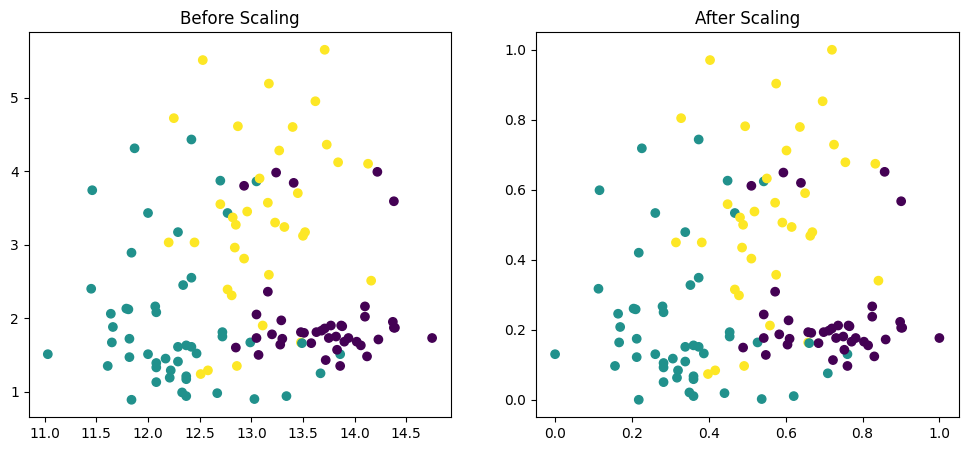

In [20]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'],c=y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'],c=y_train)
ax2.set_title("After Scaling")
plt.show()

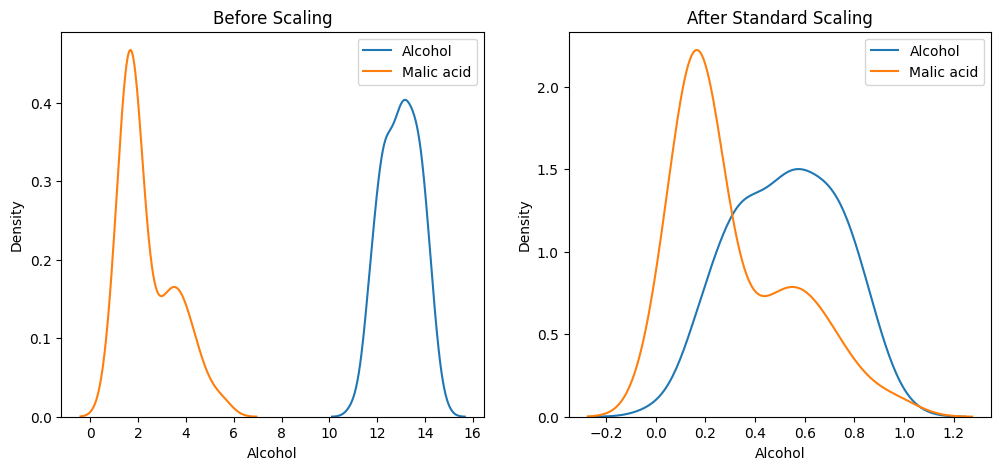

In [22]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1, label='Alcohol')
sns.kdeplot(X_train['Malic acid'], ax=ax1, label='Malic acid')
ax1.legend()

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2, label='Alcohol')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2, label='Malic acid')
ax2.legend()
plt.show()

- You can see after scaling both features came to the same scale

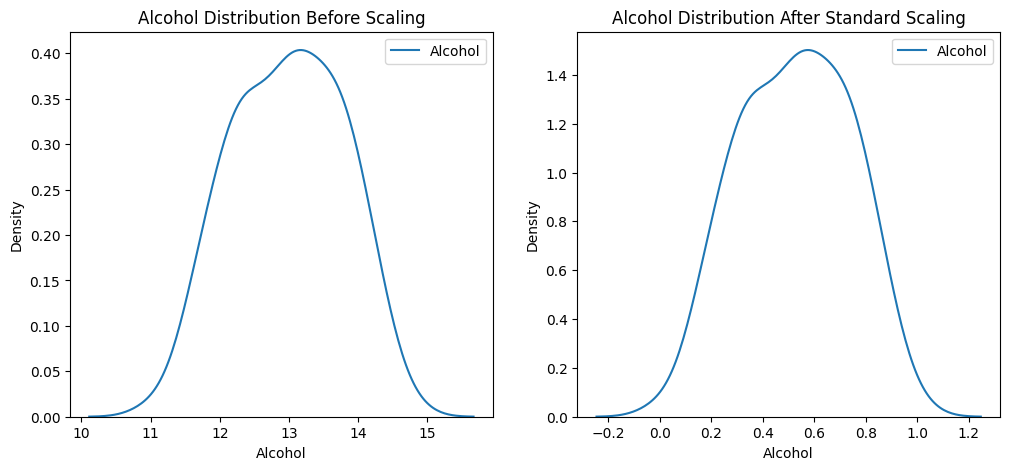

In [23]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1, label='Alcohol')
ax1.legend()

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2, label='Alcohol')
ax2.legend()
plt.show()

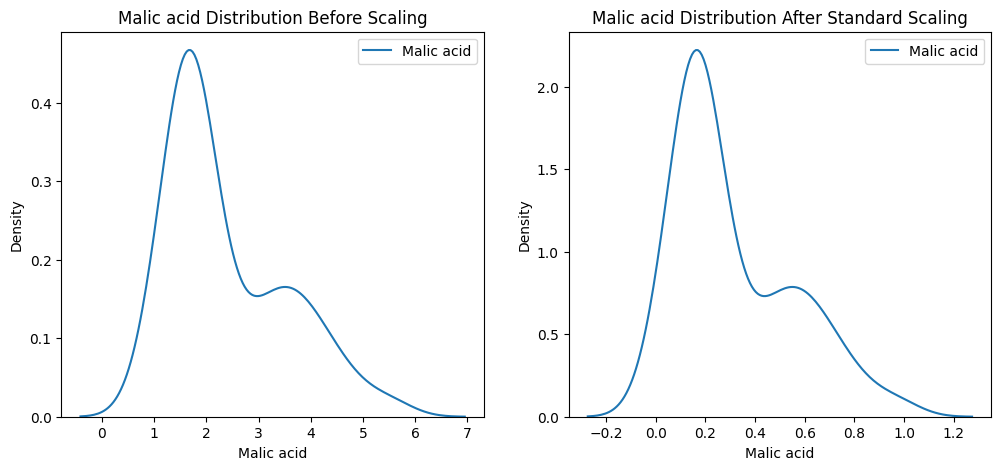

In [24]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1, label='Malic acid')
ax1.legend()

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2, label='Malic acid')
ax2.legend()
plt.show()

- For the above two features distribution is same, But in Normalization distribution might change
- Yha outlier mei vhi dikkat hota hai, as hum data ko 0 se 1 k beech mei squish krte hai, to outlier ka impact vhi kam hojata hai

## Mean Normalization

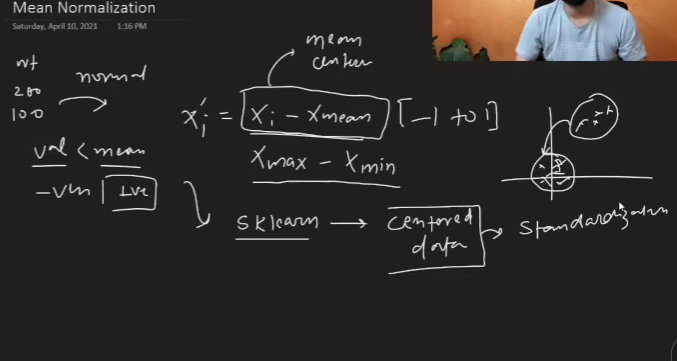

- It is used when centerded data is required. But log iske badle standardization use kr lete hai

## MaxAbs Scaling

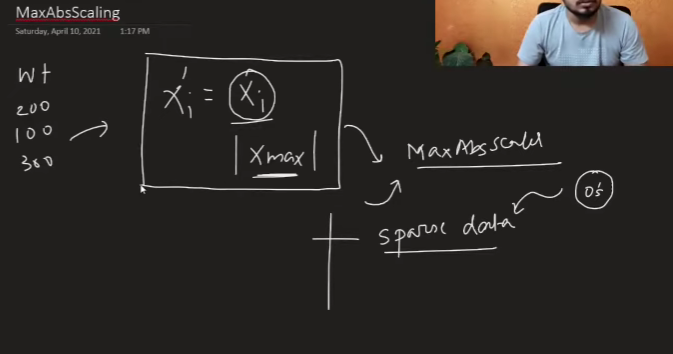

- Useful where there is sparse data(where there is a lot of 0s)

## Robust Scaling
- It is robust to outliers, agar data mei outliers hai to robust scaling use krke dekh skte ho

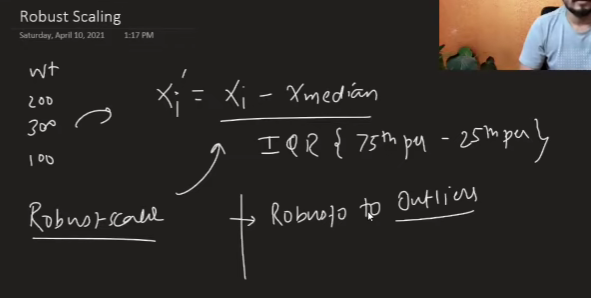

# Normalization VS Standardization

- First question to ask is feature scaling required? (For ex, decision tree mei feature scaling ki jarurat nhi hoti, but for linear regression, logistic regression, knn, svm etc. feature scaling ki jarurat hoti hai) -> This you will get to know when you will learn the algorithms, for now just know that for some algorithms feature scaling is required and for some it is not.

- If scaling is required then from experience of Campux
    - Mostly Standardization is used
    - Normalization(Specially Min-Max) is used when hume pehle se given quantity ka min-max pata hota hai (Ex. In CNN where pixel values are between 0 and 255, so we can easily apply min-max scaling to bring them between 0 and 1)
    - b aapko kuch naa pata ho to standardization use krlo, it is a good default choice.
    - Jb outliers ho to robust scaling use krlo, it is a good choice in presence of outliers.
    - Jb data sparse ho to maxabs scaling use krlo, it is a good choice for sparse data.